In [1]:
!pip install wandb huggingface_hub -q

## weights and biases login

In [2]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: happykumar_25afi21 (happykumar_25afi21-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## hugging face login

In [3]:
from huggingface_hub import notebook_login
notebook_login()

## importing libraries and setting parameters

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, create_repo

HF_REPO = "HappyKumar25afi21/exp9-gans"

WANDB_PROJECT = "exp9-gans"
EPOCHS        = 5
BATCH_SIZE    = 128
LATENT_DIM    = 100
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["bce", "lsgan", "wgan"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vanilla", "dcgan"]

print(DEVICE)

cuda


## Dataset loading

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 268kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.97MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.3MB/s]

train: 60000  test: 10000


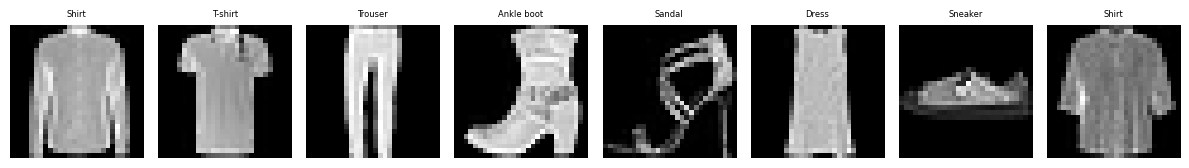

In [5]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train: {len(train_data)}  test: {len(test_data)}')

imgs, labels = next(iter(train_loader))
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## Vanilla GAN - Generator and Discriminator

In [6]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(VanillaGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super(VanillaDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

## DCGAN - Generator and Discriminator

In [7]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(DCGenerator, self).__init__()
        self.net = nn.Sequential(
            # latent -> 7x7x256
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 7x7 -> 14x14
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 14x14 -> 28x28
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7 -> 1x1
            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

## Loss Functions - BCE, LSGAN, WGAN

In [8]:
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

def disc_loss(real_out, fake_out, loss_type):
    if loss_type == 'bce':
        real_loss = bce(real_out, torch.ones_like(real_out))
        fake_loss = bce(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'lsgan':
        real_loss = mse(real_out, torch.ones_like(real_out))
        fake_loss = mse(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'wgan':
        return -(real_out.mean() - fake_out.mean())

def gen_loss(fake_out, loss_type):
    if loss_type == 'bce':
        return bce(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'lsgan':
        return mse(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'wgan':
        return -fake_out.mean()

## Optimizer Factory

In [9]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=2e-4, betas=(0.5, 0.999))
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    else:
        return optim.RMSprop(model.parameters(), lr=5e-5)

## Training Loop

In [10]:
def train_epoch(G, D, loader, opt_g, opt_d, loss_type):
    G.train(); D.train()
    g_running = 0
    d_running = 0

    for real, _ in loader:
        real = real.to(DEVICE)
        bs   = real.size(0)

        # train discriminator
        z         = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake      = G(z).detach()
        real_out  = D(real)
        fake_out  = D(fake)
        d_loss    = disc_loss(real_out, fake_out, loss_type)
        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # weight clipping for wgan
        if loss_type == 'wgan':
            for p in D.parameters():
                p.data.clamp_(-0.01, 0.01)

        # train generator
        z        = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake     = G(z)
        fake_out = D(fake)
        g_loss   = gen_loss(fake_out, loss_type)
        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        g_running += g_loss.item()
        d_running += d_loss.item()

    n = len(loader)
    return g_running / n, d_running / n

## Visualization

In [11]:
def show_generated(G, epoch, tag, n=16):
    G.eval()
    with torch.no_grad():
        z    = torch.randn(n, LATENT_DIM).to(DEVICE)
        imgs = G(z).cpu()
    imgs = (imgs + 1) / 2
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'epoch {epoch} - {tag}', fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

## Main Experiment Runner

In [12]:
results       = {}
saved_generators = {}

def run_experiment(arch, loss_type, opt_name):
    name = f'{arch}_{loss_type}_{opt_name}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type, 'optimizer': opt_name, 'epochs': EPOCHS
    })

    if arch == 'vanilla':
        G = VanillaGenerator(LATENT_DIM).to(DEVICE)
        D = VanillaDiscriminator().to(DEVICE)
    else:
        G = DCGenerator(LATENT_DIM).to(DEVICE)
        D = DCDiscriminator().to(DEVICE)

    opt_g = get_optimizer(G, opt_name)
    opt_d = get_optimizer(D, opt_name)

    g_losses = []
    d_losses = []

    for epoch in range(1, EPOCHS + 1):
        g_loss, d_loss = train_epoch(G, D, train_loader, opt_g, opt_d, loss_type)
        g_losses.append(g_loss)
        d_losses.append(d_loss)
        wandb.log({'epoch': epoch, 'g_loss': g_loss, 'd_loss': d_loss})
        print(f'  epoch {epoch}/{EPOCHS}  g_loss={g_loss:.4f}  d_loss={d_loss:.4f}')

        if epoch % 5 == 0 or epoch == EPOCHS:
            fig = show_generated(G, epoch, name)
            wandb.log({f'generated_ep{epoch}': wandb.Image(fig)})
            plt.close(fig)

    # loss curves
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(g_losses, label='generator')
    ax.plot(d_losses, label='discriminator')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(name)
    ax.legend()
    plt.tight_layout()
    plt.show()
    wandb.log({'loss_curve': wandb.Image(fig)})
    plt.close(fig)

    torch.save(G.state_dict(), f'{name}_G.pt')
    torch.save(D.state_dict(), f'{name}_D.pt')
    saved_generators[name] = G
    results[name] = {'g_loss': g_losses[-1], 'd_loss': d_losses[-1]}

    wandb.finish()
    return G, D

## Quick Test


starting: vanilla_bce_adam


  epoch 1/5  g_loss=1.2081  d_loss=0.4765
  epoch 2/5  g_loss=1.8120  d_loss=0.4490
  epoch 3/5  g_loss=1.9880  d_loss=0.4432
  epoch 4/5  g_loss=1.7381  d_loss=0.4907
  epoch 5/5  g_loss=1.4643  d_loss=0.5367


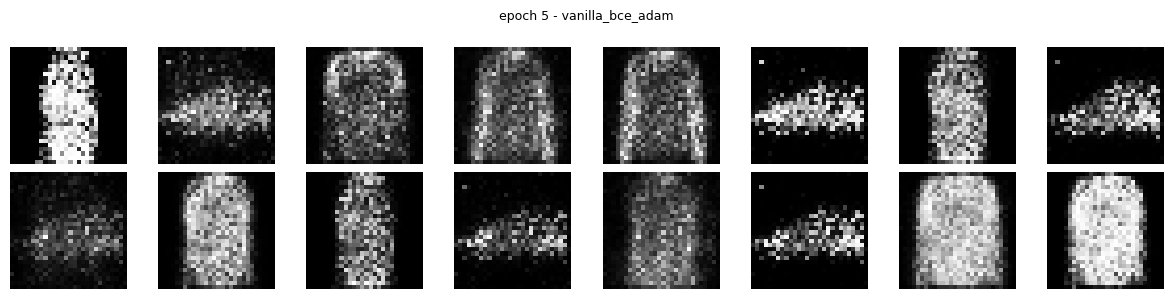

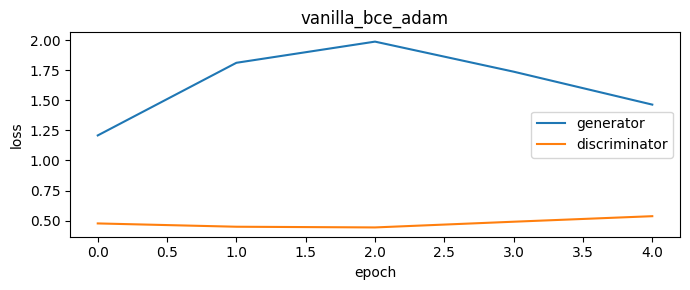

d_loss,▃▁▁▅█
epoch,▁▃▅▆█
g_loss,▁▆█▆▃
d_loss,0.53673
epoch,5
g_loss,1.46431



starting: dcgan_bce_adam


  epoch 1/5  g_loss=1.4282  d_loss=0.4143
  epoch 2/5  g_loss=1.2138  d_loss=0.4693
  epoch 3/5  g_loss=1.0660  d_loss=0.5384
  epoch 4/5  g_loss=1.0374  d_loss=0.5566
  epoch 5/5  g_loss=1.0693  d_loss=0.5471


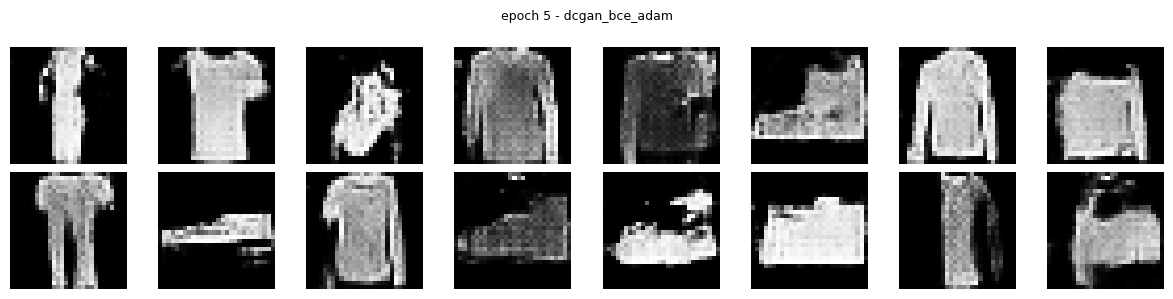

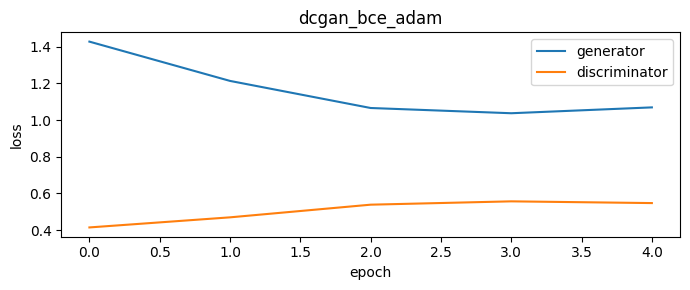

d_loss,▁▄▇██
epoch,▁▃▅▆█
g_loss,█▄▂▁▂
d_loss,0.54714
epoch,5
g_loss,1.06933


(DCGenerator(
   (net): Sequential(
     (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
     (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): ReLU(inplace=True)
     (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (7): Tanh()
   )
 ),
 DCDiscriminator(
   (net): Sequential(
     (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (1): LeakyReLU(negative_slope=0.2, inplace=True)
     (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (4): LeakyReLU(negative_slope=0.2, inplace=True)
    

In [13]:
run_experiment('vanilla', 'bce', 'adam')
run_experiment('dcgan',   'bce', 'adam')

## Full Grid - all combinations


starting: vanilla_bce_adam


  epoch 1/5  g_loss=1.1088  d_loss=0.4979
  epoch 2/5  g_loss=1.8533  d_loss=0.4739
  epoch 3/5  g_loss=1.7774  d_loss=0.4893
  epoch 4/5  g_loss=1.6182  d_loss=0.5082
  epoch 5/5  g_loss=1.4693  d_loss=0.5275


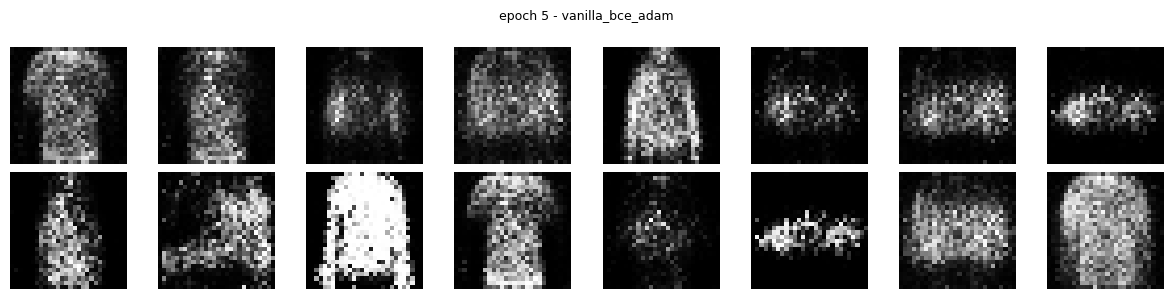

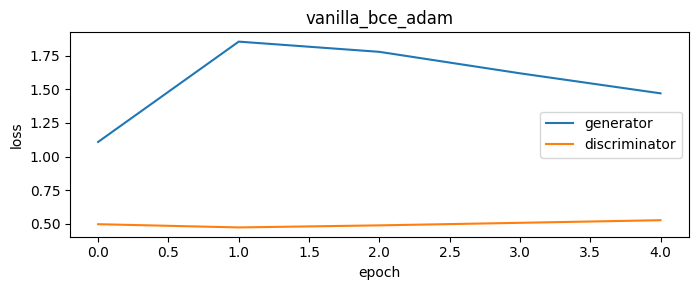

d_loss,▄▁▃▅█
epoch,▁▃▅▆█
g_loss,▁█▇▆▄
d_loss,0.52754
epoch,5
g_loss,1.46934



starting: vanilla_bce_sgd


  epoch 1/5  g_loss=0.7719  d_loss=0.3828
  epoch 2/5  g_loss=1.4785  d_loss=0.2951
  epoch 3/5  g_loss=2.3028  d_loss=0.1563
  epoch 4/5  g_loss=2.8129  d_loss=0.1217
  epoch 5/5  g_loss=3.0782  d_loss=0.1496


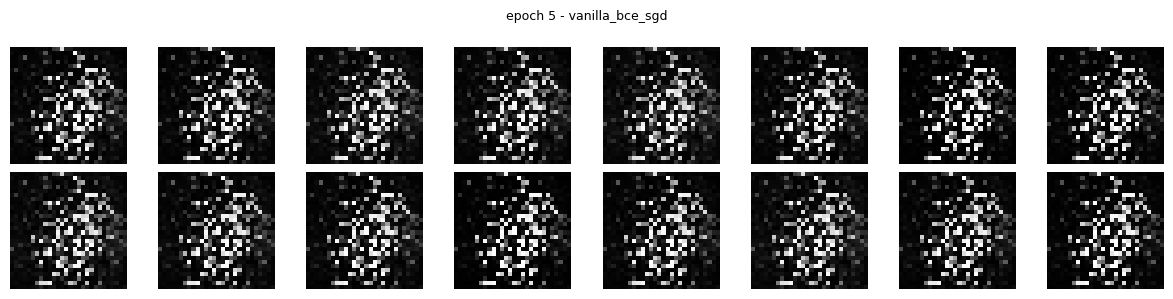

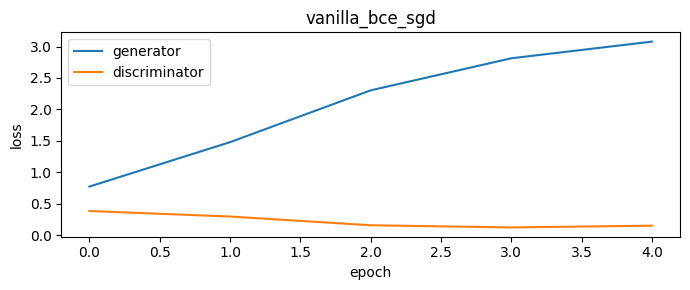

d_loss,█▆▂▁▂
epoch,▁▃▅▆█
g_loss,▁▃▆▇█
d_loss,0.14959
epoch,5
g_loss,3.07816



starting: vanilla_bce_rmsprop


  epoch 1/5  g_loss=0.8372  d_loss=0.4767
  epoch 2/5  g_loss=1.3611  d_loss=0.3727
  epoch 3/5  g_loss=2.0254  d_loss=0.2929
  epoch 4/5  g_loss=2.4299  d_loss=0.2583
  epoch 5/5  g_loss=2.7385  d_loss=0.2492


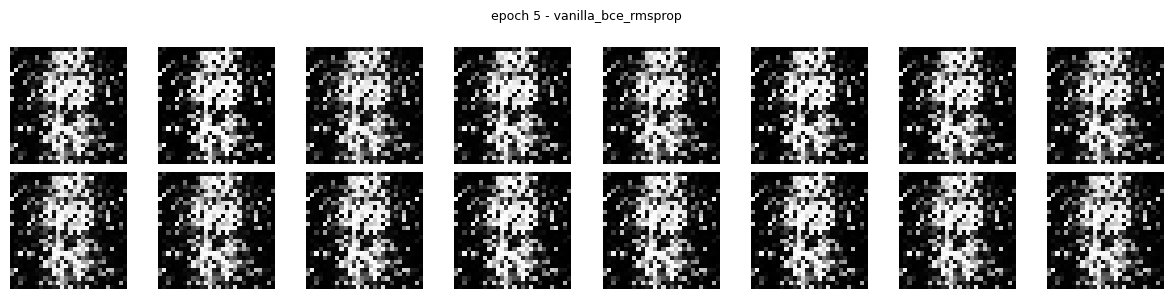

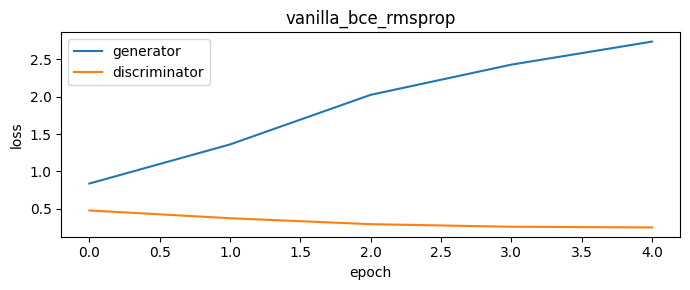

d_loss,█▅▂▁▁
epoch,▁▃▅▆█
g_loss,▁▃▅▇█
d_loss,0.24919
epoch,5
g_loss,2.73847



starting: vanilla_lsgan_adam


  epoch 1/5  g_loss=1.0353  d_loss=0.0652
  epoch 2/5  g_loss=0.8115  d_loss=0.1139
  epoch 3/5  g_loss=0.6575  d_loss=0.1513
  epoch 4/5  g_loss=0.6382  d_loss=0.1548
  epoch 5/5  g_loss=0.5801  d_loss=0.1664


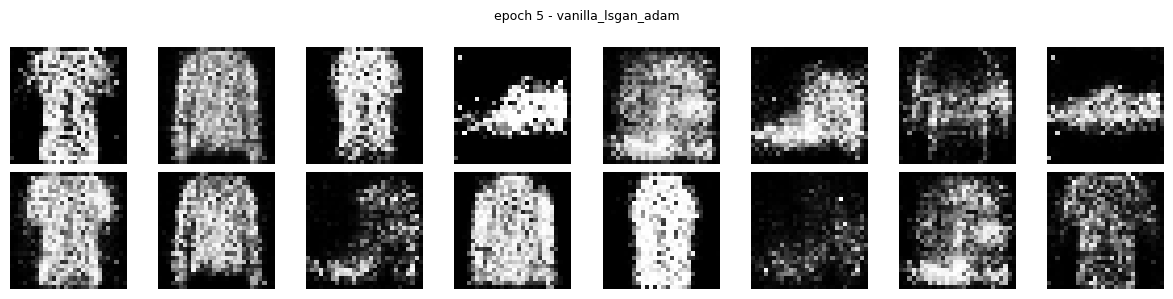

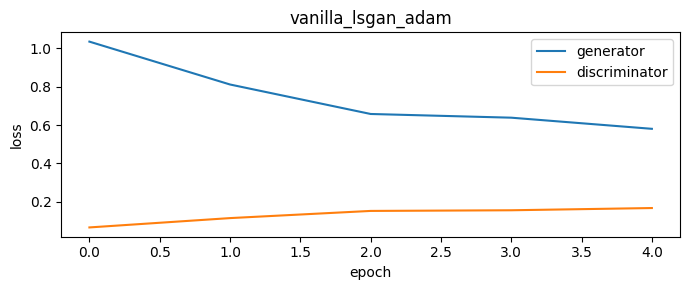

d_loss,▁▄▇▇█
epoch,▁▃▅▆█
g_loss,█▅▂▂▁
d_loss,0.16642
epoch,5
g_loss,0.58008



starting: vanilla_lsgan_sgd


  epoch 1/5  g_loss=0.7069  d_loss=0.0385
  epoch 2/5  g_loss=0.9923  d_loss=0.0340
  epoch 3/5  g_loss=0.9948  d_loss=0.0216
  epoch 4/5  g_loss=0.9799  d_loss=0.0232
  epoch 5/5  g_loss=0.9501  d_loss=0.0259


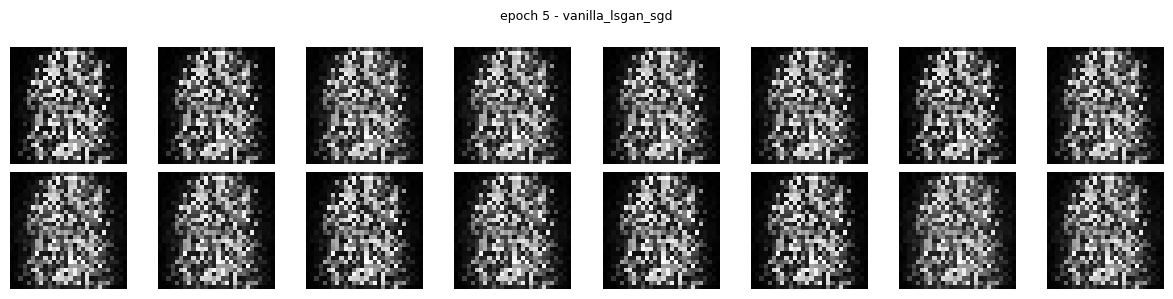

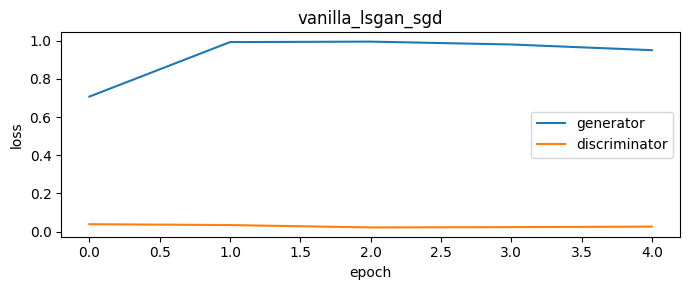

d_loss,█▆▁▂▃
epoch,▁▃▅▆█
g_loss,▁███▇
d_loss,0.02585
epoch,5
g_loss,0.95009



starting: vanilla_lsgan_rmsprop


  epoch 1/5  g_loss=0.8220  d_loss=0.0769
  epoch 2/5  g_loss=0.8880  d_loss=0.0878
  epoch 3/5  g_loss=0.9355  d_loss=0.0839
  epoch 4/5  g_loss=0.9136  d_loss=0.0898
  epoch 5/5  g_loss=0.9167  d_loss=0.0871


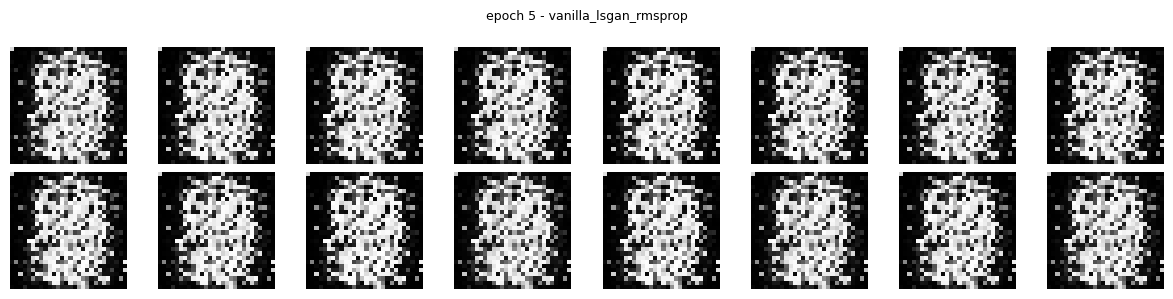

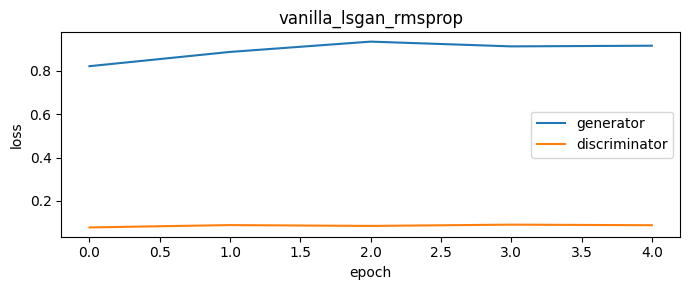

d_loss,▁▇▅█▇
epoch,▁▃▅▆█
g_loss,▁▅█▇▇
d_loss,0.08713
epoch,5
g_loss,0.91666



starting: vanilla_wgan_adam


  epoch 1/5  g_loss=-0.7309  d_loss=-0.6376
  epoch 2/5  g_loss=-0.2537  d_loss=-0.1530
  epoch 3/5  g_loss=-0.0031  d_loss=-0.0790
  epoch 4/5  g_loss=-0.0118  d_loss=-0.1434
  epoch 5/5  g_loss=-0.0936  d_loss=-0.1458


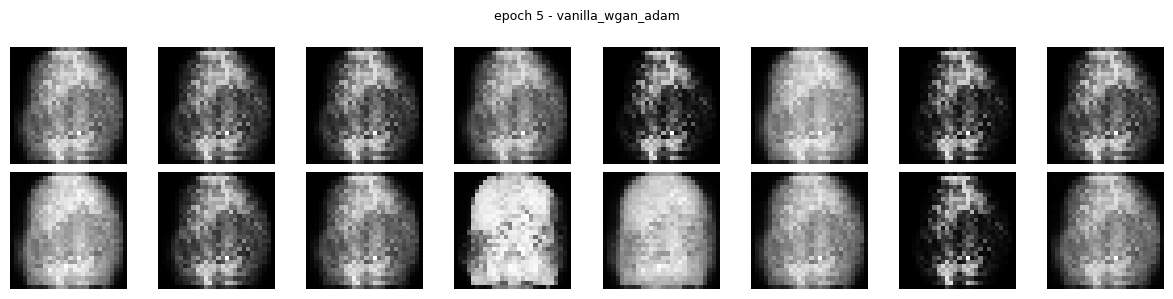

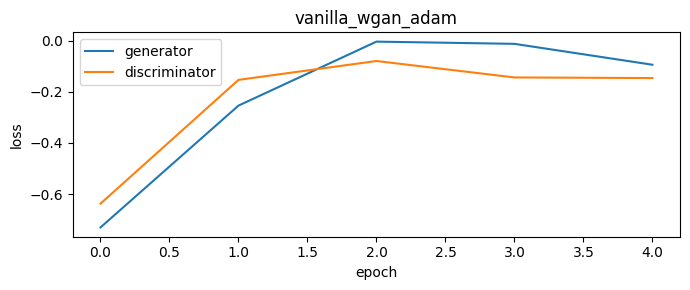

d_loss,▁▇█▇▇
epoch,▁▃▅▆█
g_loss,▁▆██▇
d_loss,-0.14583
epoch,5
g_loss,-0.09358



starting: vanilla_wgan_sgd


  epoch 1/5  g_loss=0.2711  d_loss=-1.8353
  epoch 2/5  g_loss=2.0645  d_loss=-0.7613
  epoch 3/5  g_loss=2.7377  d_loss=-0.8954
  epoch 4/5  g_loss=-1.2799  d_loss=-2.9687
  epoch 5/5  g_loss=3.8861  d_loss=-0.9216


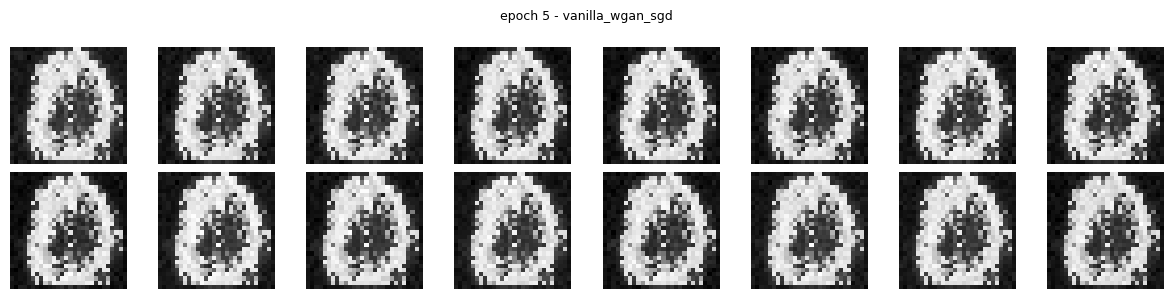

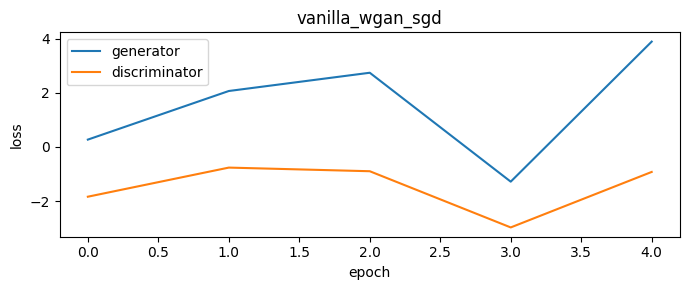

d_loss,▅██▁▇
epoch,▁▃▅▆█
g_loss,▃▆▆▁█
d_loss,-0.92157
epoch,5
g_loss,3.88608



starting: vanilla_wgan_rmsprop


  epoch 1/5  g_loss=-0.0734  d_loss=-0.2034
  epoch 2/5  g_loss=-0.1097  d_loss=-0.2787
  epoch 3/5  g_loss=-0.7181  d_loss=-0.4508
  epoch 4/5  g_loss=-0.6974  d_loss=-0.6236
  epoch 5/5  g_loss=-0.5397  d_loss=-0.6112


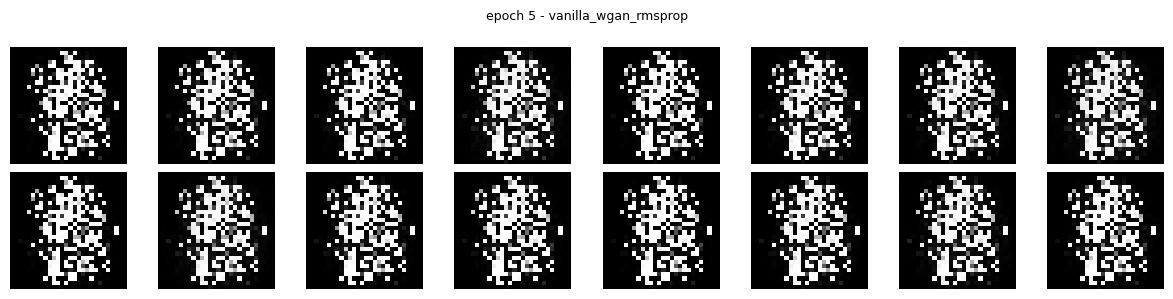

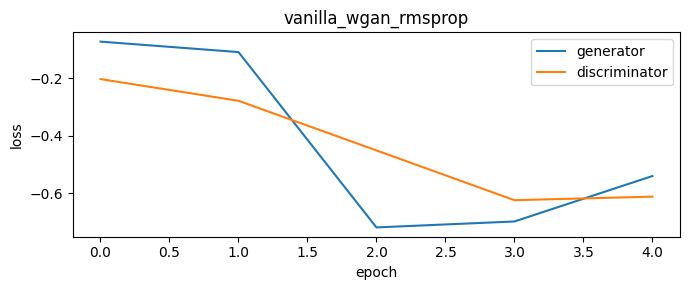

d_loss,█▇▄▁▁
epoch,▁▃▅▆█
g_loss,██▁▁▃
d_loss,-0.61123
epoch,5
g_loss,-0.53973



starting: dcgan_bce_adam


  epoch 1/5  g_loss=5.3839  d_loss=0.0336
  epoch 2/5  g_loss=8.1898  d_loss=0.0004
  epoch 3/5  g_loss=7.3591  d_loss=0.0176
  epoch 4/5  g_loss=6.7259  d_loss=0.0820
  epoch 5/5  g_loss=1.5414  d_loss=0.3694


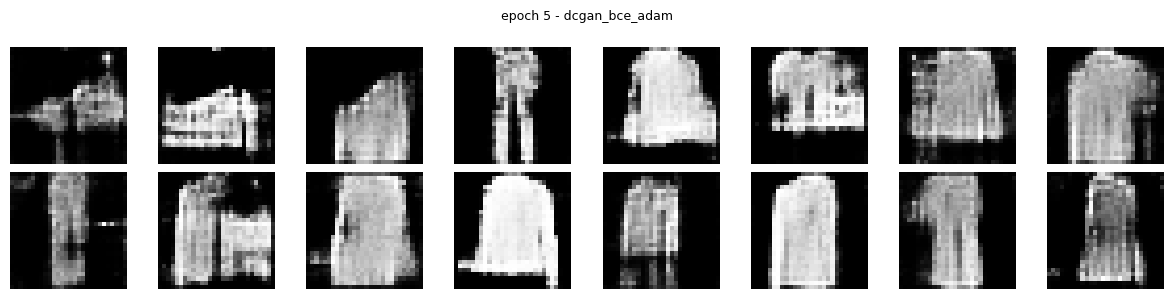

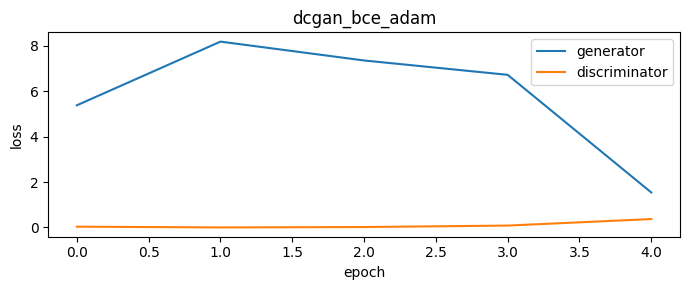

d_loss,▂▁▁▃█
epoch,▁▃▅▆█
g_loss,▅█▇▆▁
d_loss,0.36942
epoch,5
g_loss,1.54141



starting: dcgan_bce_sgd


  epoch 1/5  g_loss=7.3607  d_loss=0.0254
  epoch 2/5  g_loss=8.0893  d_loss=0.0006
  epoch 3/5  g_loss=7.9590  d_loss=0.0007
  epoch 4/5  g_loss=8.6403  d_loss=0.0016
  epoch 5/5  g_loss=7.9706  d_loss=0.0006


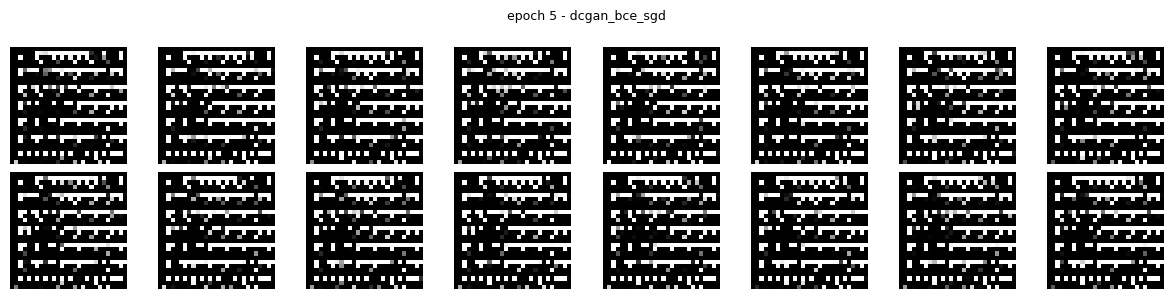

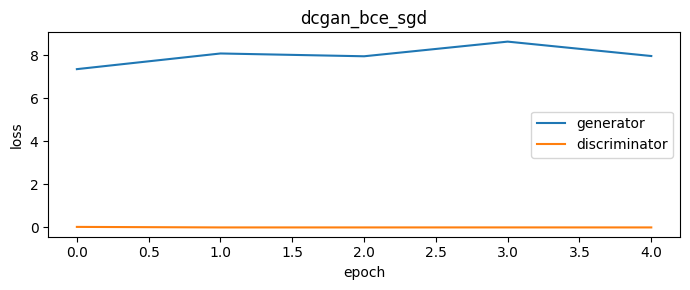

d_loss,█▁▁▁▁
epoch,▁▃▅▆█
g_loss,▁▅▄█▄
d_loss,0.0006
epoch,5
g_loss,7.97064



starting: dcgan_bce_rmsprop


  epoch 1/5  g_loss=1.1799  d_loss=0.4418
  epoch 2/5  g_loss=1.4765  d_loss=0.3213
  epoch 3/5  g_loss=1.3473  d_loss=0.3757
  epoch 4/5  g_loss=1.2345  d_loss=0.4254
  epoch 5/5  g_loss=1.1647  d_loss=0.4652


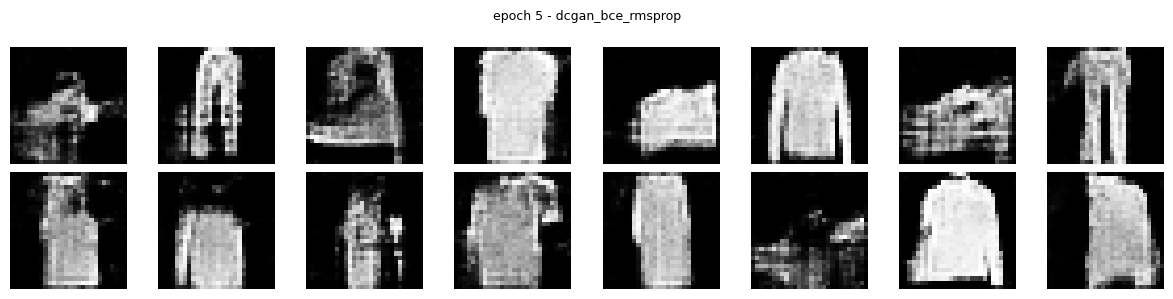

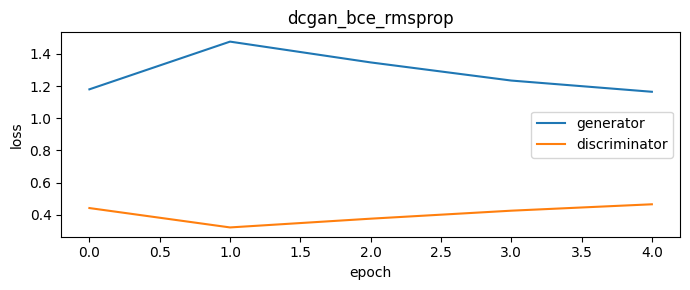

d_loss,▇▁▄▆█
epoch,▁▃▅▆█
g_loss,▁█▅▃▁
d_loss,0.46518
epoch,5
g_loss,1.16472



starting: dcgan_lsgan_adam


  epoch 1/5  g_loss=0.6862  d_loss=0.1574
  epoch 2/5  g_loss=0.6015  d_loss=0.1326
  epoch 3/5  g_loss=0.5056  d_loss=0.1708
  epoch 4/5  g_loss=0.4652  d_loss=0.1924
  epoch 5/5  g_loss=0.4504  d_loss=0.1941


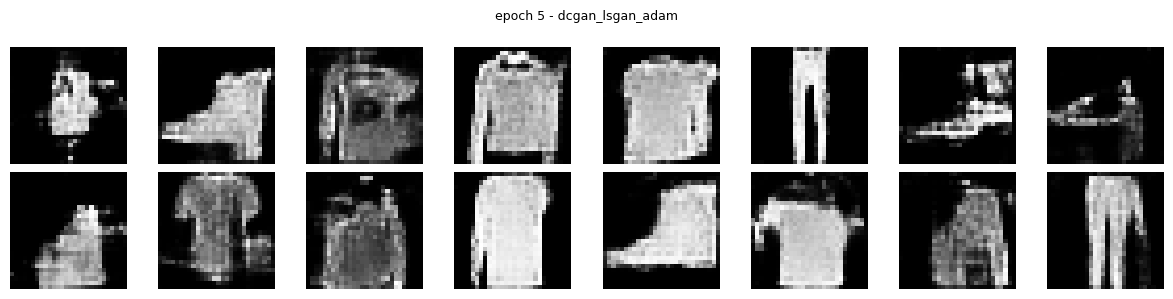

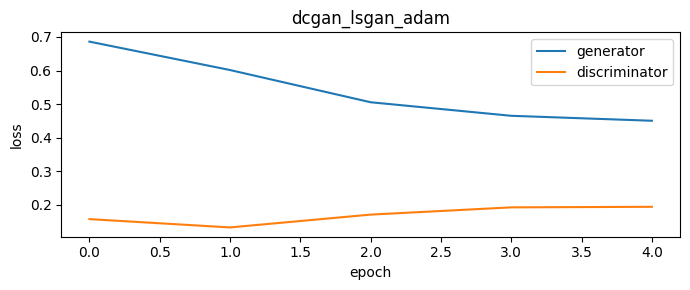

d_loss,▄▁▅██
epoch,▁▃▅▆█
g_loss,█▅▃▁▁
d_loss,0.19409
epoch,5
g_loss,0.45044



starting: dcgan_lsgan_sgd


  epoch 1/5  g_loss=1.1779  d_loss=0.0891
  epoch 2/5  g_loss=1.0183  d_loss=0.0039
  epoch 3/5  g_loss=1.0728  d_loss=0.0220
  epoch 4/5  g_loss=1.0096  d_loss=0.0025
  epoch 5/5  g_loss=1.0096  d_loss=0.0025


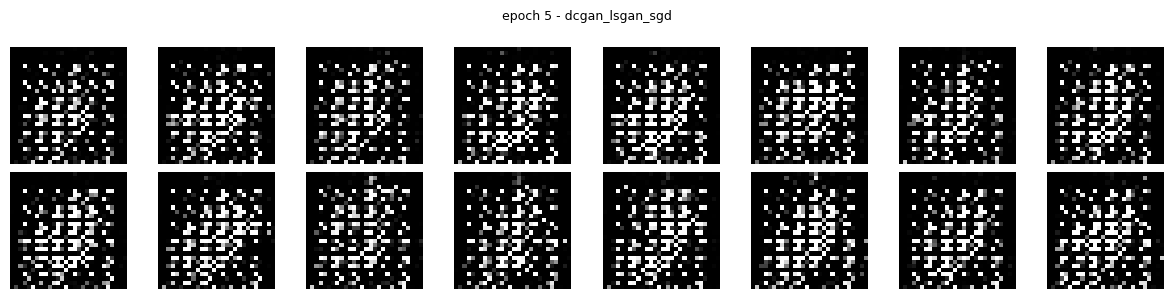

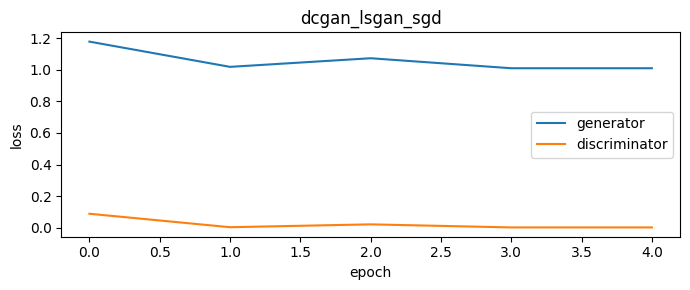

d_loss,█▁▃▁▁
epoch,▁▃▅▆█
g_loss,█▁▄▁▁
d_loss,0.00252
epoch,5
g_loss,1.00956



starting: dcgan_lsgan_rmsprop


  epoch 1/5  g_loss=0.9881  d_loss=0.0528
  epoch 2/5  g_loss=1.0116  d_loss=0.0181
  epoch 3/5  g_loss=1.0118  d_loss=0.0145
  epoch 4/5  g_loss=1.0138  d_loss=0.0124
  epoch 5/5  g_loss=1.0219  d_loss=0.0141


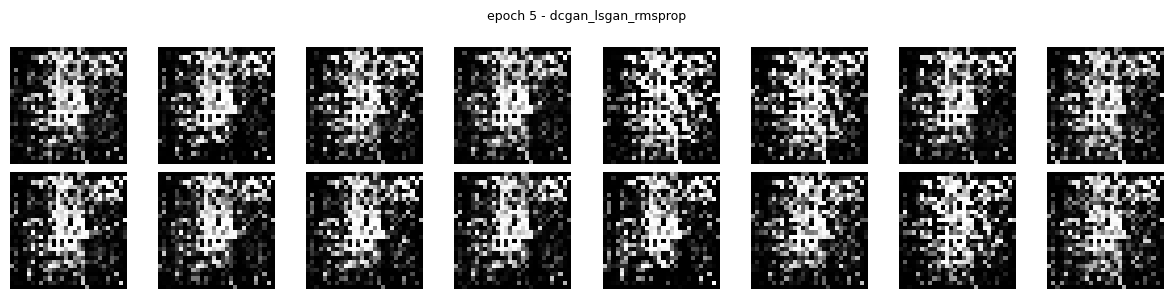

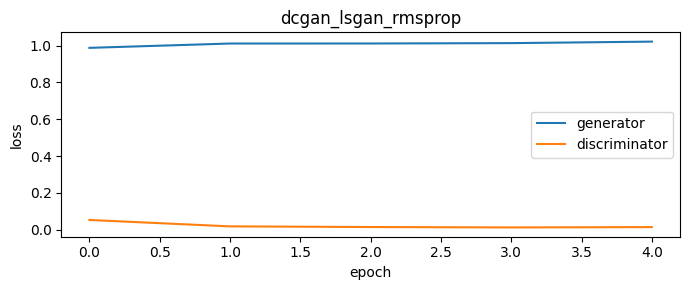

d_loss,█▂▁▁▁
epoch,▁▃▅▆█
g_loss,▁▆▆▆█
d_loss,0.0141
epoch,5
g_loss,1.02193



starting: dcgan_wgan_adam


  epoch 1/5  g_loss=0.0337  d_loss=-0.0369
  epoch 2/5  g_loss=0.0263  d_loss=-0.0087
  epoch 3/5  g_loss=0.0222  d_loss=-0.0085
  epoch 4/5  g_loss=0.0218  d_loss=-0.0079
  epoch 5/5  g_loss=0.0172  d_loss=-0.0066


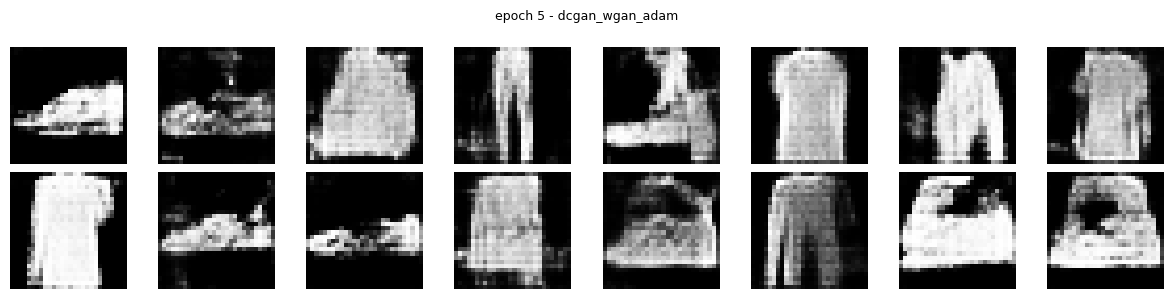

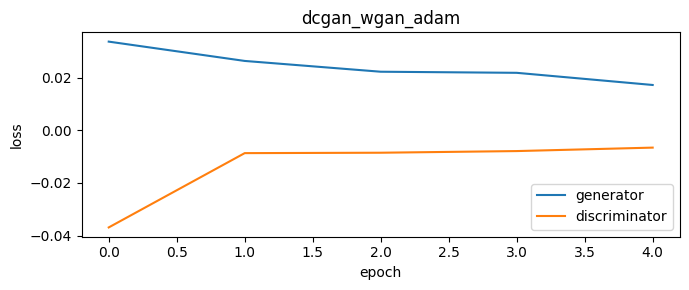

d_loss,▁████
epoch,▁▃▅▆█
g_loss,█▅▃▃▁
d_loss,-0.00659
epoch,5
g_loss,0.01721



starting: dcgan_wgan_sgd


  epoch 1/5  g_loss=0.2338  d_loss=-0.4624
  epoch 2/5  g_loss=0.4352  d_loss=-0.8217
  epoch 3/5  g_loss=0.4017  d_loss=-0.7883
  epoch 4/5  g_loss=0.4190  d_loss=-0.8382
  epoch 5/5  g_loss=0.4039  d_loss=-0.8080


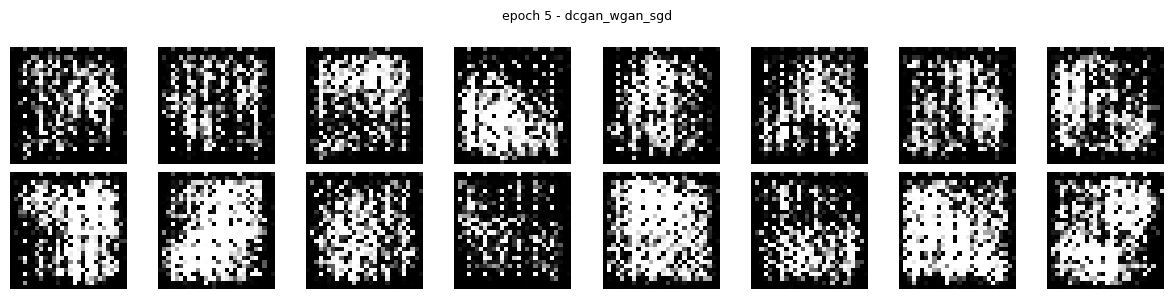

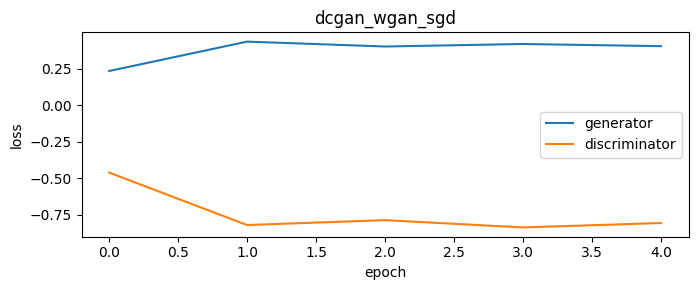

d_loss,█▁▂▁▂
epoch,▁▃▅▆█
g_loss,▁█▇▇▇
d_loss,-0.80801
epoch,5
g_loss,0.40392



starting: dcgan_wgan_rmsprop


  epoch 1/5  g_loss=-0.0078  d_loss=-0.0014
  epoch 2/5  g_loss=-0.0058  d_loss=-0.0094
  epoch 3/5  g_loss=-0.0091  d_loss=-0.0181
  epoch 4/5  g_loss=-0.0051  d_loss=-0.0170
  epoch 5/5  g_loss=-0.0044  d_loss=-0.0134


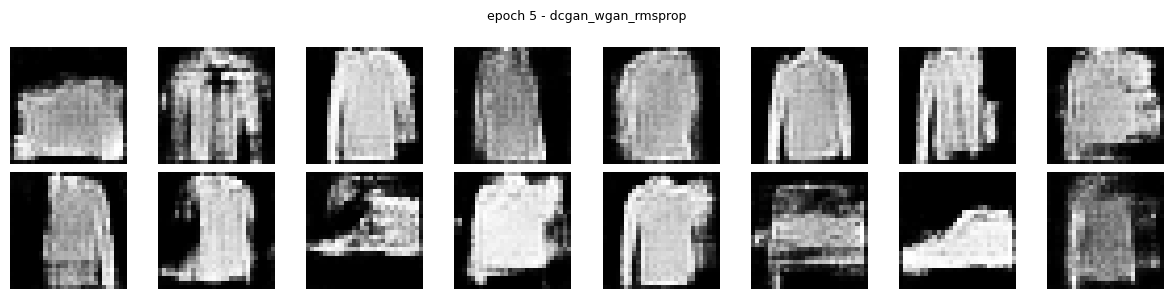

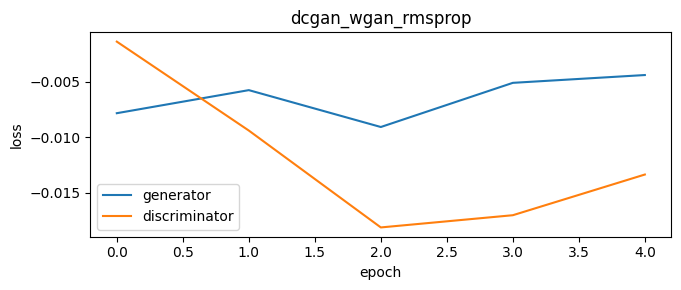

d_loss,█▅▁▁▃
epoch,▁▃▅▆█
g_loss,▃▆▁▇█
d_loss,-0.01336
epoch,5
g_loss,-0.00439


In [14]:
for arch in MODELS:
    for lf in LOSS_FNS:
        for opt in OPTIMIZERS:
            run_experiment(arch, lf, opt)

## Results Summary

In [15]:
print(f'{"config":<35} {"g_loss":>10} {"d_loss":>10}')
print('-' * 57)
for k, v in sorted(results.items(), key=lambda x: x[1]['g_loss']):
    print(f'{k:<35} {v["g_loss"]:>10.4f} {v["d_loss"]:>10.4f}')

config                                  g_loss     d_loss
---------------------------------------------------------
vanilla_wgan_rmsprop                   -0.5397    -0.6112
vanilla_wgan_adam                      -0.0936    -0.1458
dcgan_wgan_rmsprop                     -0.0044    -0.0134
dcgan_wgan_adam                         0.0172    -0.0066
dcgan_wgan_sgd                          0.4039    -0.8080
dcgan_lsgan_adam                        0.4504     0.1941
vanilla_lsgan_adam                      0.5801     0.1664
vanilla_lsgan_rmsprop                   0.9167     0.0871
vanilla_lsgan_sgd                       0.9501     0.0259
dcgan_lsgan_sgd                         1.0096     0.0025
dcgan_lsgan_rmsprop                     1.0219     0.0141
dcgan_bce_rmsprop                       1.1647     0.4652
vanilla_bce_adam                        1.4693     0.5275
dcgan_bce_adam                          1.5414     0.3694
vanilla_bce_rmsprop                     2.7385     0.2492
vanilla_bce_sg

## Upload to HuggingFace

In [16]:
from huggingface_hub import login
login()

In [17]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_generators.keys():
    for suffix in ['_G.pt', '_D.pt']:
        fname = f'{name}{suffix}'
        if os.path.exists(fname):
            api.upload_file(
                path_or_fileobj=fname,
                path_in_repo=f'models/{fname}',
                repo_id=HF_REPO
            )
            print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

uploaded: vanilla_bce_adam_G.pt


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

uploaded: dcgan_wgan_rmsprop_G.pt


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

uploaded: dcgan_wgan_rmsprop_D.pt
https://huggingface.co/HappyKumar25afi21/exp9-gans


In [18]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/happykumar_25afi21-delhi-technological-university/exp9-gans
HF  : https://huggingface.co/HappyKumar25afi21/exp9-gans
